# Valoración de la cartera "Lending Club" para adquisición.

Nuestra entidad está evaluando la compra de una cartera de créditos al consumo originada por la plataforma Lending Club. El equipo de Inversiones está emocionado porque los tipos de interés de estos préstamos parecen muy rentables. Sin embargo, desde el departamento de Riesgos y bajo la atenta mirada del regulador, sabemos que la rentabilidad no es nada si no somos capaces de estimar el riesgo real de impago y la pérdida económica que nos va a suponer.

No voy a aprobar esta compra basándome en intuiciones. Necesito que construyáis un motor de Credit Scoring y Valoración de Pérdida Esperada (Expected Loss) desde cero.

Vuestro objetivo final no es entregarme un modelo con un buen "Accuracy". Vuestro objetivo es darme una cifra en euros: ¿Cuánto dinero estimamos que vamos a perder de esta cartera?

Para ello, tendréis que calcular la fórmula reina del riesgo de crédito:

$$
Pérdida Esperada (EL) = PD × LGD × EAD
$$


## 🗺️ Tu Misión (Hoja de Ruta)

El proyecto se divide en 4 fases críticas. Deberéis documentar cada decisión que toméis. Si borráis nulos o agrupáis categorías, quiero saber por qué lo hacéis desde el punto de vista de negocio. Podéis utilizar cualquier modelo de Machine Learning que consideréis oportuno para cada fase.

### Fase 1: Limpieza de Datos y Definición del Problema (Data Preparation)
El archivo que nos han enviado desde Lending Club tiene datos de clientes reales. Eso significa ruido, valores atípicos y nulos.

- Análisis Exploratorio (EDA): Identificad qué variables tenemos. ¿Hay desbalanceo? ¿Qué hacemos con las profesiones raras o los valores extremos en ingresos?

**Definición de los Parámetros de Riesgo:**

- PD (Probability of Default): Se calculará como una probabilidad matemática sin más. Deberéis crear una variable objetivo binaria (0/1) a partir del estado del préstamo, donde los impagados son un 1 y los pagados un 0.

- LGD (Loss Given Default / Severidad): Para calcular la pérdida real, utilizaréis la siguiente fórmula exacta en vuestro código:

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; ``df['Loss'] = 100 * df['max_bal_owed'] / df['funded_amnt']``

- EAD (Exposure At Default): La exposición será directamente la cantidad financiada inicial (``funded_amnt``).


### Diccionario de Datos: Cartera Lending Club

| Variable Original | Nombre en Español | Definición Técnica |
| :--- | :--- | :--- |
| `funded_amnt` | **monto_financiado** | Monto total comprometido para el préstamo en el momento de la emisión. |
| `interest_rate` | **tasa_interes** | Tasa de interés anual del préstamo. |
| `monthly_payment` | **pago_mensual** | Cuota mensual que el prestatario debe pagar si el préstamo se origina. |
| `grade` | **grado** | Calificación de riesgo asignada por Lending Club (de A5 a C1). |
| `loan_term_months` | **plazo_prestamo_meses** | Duración del préstamo en meses (ej. 36 o 60). |
| `loan_purpose` | **proposito_prestamo** | Categoría del motivo del préstamo (deuda, mejoras hogar, etc.). |
| `disbursement_method` | **metodo_desembolso** | Forma en que se entregó el dinero (Efectivo o Pago Directo). |
| `issue_date_month` | **mes_emision** | Mes en el que se financió el préstamo. |
| `issue_date_year` | **anio_emision** | Año en el que se financió el préstamo. |
| `emp_title` | **titulo_empleo** | Puesto de trabajo proporcionado por el prestatario. |
| `emp_length` | **antiguedad_empleo** | Años de experiencia laboral (0 a 10+ años). |
| `home_ownership_status` | **estado_vivienda** | Situación de la vivienda (Renta, Propia, Hipoteca). |
| `annual_income` | **ingreso_anual** | Ingresos anuales declarados por el prestatario. |
| `verification_status` | **estado_verificacion** | Indica si los ingresos fueron verificados por la plataforma. |
| `addr_state` | **estado_residencia** | Estado de EE.UU. donde reside el prestatario. |
| `region_code` | **codigo_region** | Código numérico de la región geográfica. |
| `dept_paym_income_ratio` | **ratio_deuda_ingresos** | Porcentaje de ingresos que se destinan al pago de deudas (DTI). |
| `num_30+_delinq_in_2yrs` | **num_moras_30_dias_2anios** | Veces que ha incurrido en mora de 30+ días en los últimos 2 años. |
| `num_inq_in_6mths` | **num_consultas_6meses** | Consultas de crédito en los últimos 6 meses (excl. automotrices). |
| `num_inq_in_12mths` | **num_consultas_12meses** | Consultas de crédito en los últimos 12 meses. |
| `num_inq` | **num_consultas_totales** | Total de consultas de crédito registradas en su historial. |
| `mths_since_last_delinq` | **meses_desde_ultima_mora** | Tiempo transcurrido desde la última mora registrada. |
| `num_open_credit_lines` | **num_lineas_credito_abiertas** | Número de líneas de crédito activas actualmente. |
| `num_derogatory_pub_rec` | **num_registros_negativos** | Número de registros públicos desfavorables (quiebras, etc.). |
| `total_credit_revolving_bal` | **saldo_revolvente_total** | Saldo total en tarjetas de crédito y líneas revolventes. |
| `used_credit_share` | **porcentaje_credito_utilizado** | Ratio de saldo revolvente sobre el límite de crédito total. |
| `tot_num_credit_lines` | **num_total_lineas_credito** | Total de líneas de crédito que ha tenido el cliente. |
| `initial_list_status` | **estado_listado_inicial** | Estado inicial del listado del préstamo (W o F). |
| `earliest_cr_line_month` | **mes_primera_linea_credito** | Mes en que se abrió la primera línea de crédito reportada. |
| `earliest_cr_line_year` | **anio_primera_linea_credito** | Año en que se abrió la primera línea de crédito reportada. |
| `remaining_princ_for_tot_amnt_fund` | **capital_pendiente_total** | Capital que aún no se ha recuperado del monto financiado. |
| `paym_rec_for_tot_amnt_fund` | **pagos_recibidos_total** | Total de pagos (capital + interés) recibidos hasta hoy. |
| `princ_rec` | **capital_recibido** | Solo el capital que ha sido recuperado hasta la fecha. |
| `interest_rec` | **intereses_recibidos** | Solo los intereses recuperados hasta la fecha. |
| `late_fees_rec` | **comisiones_mora_recibidas** | Comisiones por pagos atrasados recolectadas. |
| `max_bal_owed` | **saldo_maximo_adeudado** | El saldo máximo que el cliente ha llegado a deber. |
| `bal_to_cred_lim` | **saldo_vs_limite_credito** | Saldo actual frente al límite total de sus cuentas revolventes. |
| `num_open_trades_in_6mths` | **num_operaciones_abiertas_6meses** | Cuentas de crédito abiertas en el último semestre. |
| `num_installment_acc_op_in_12mths` | **num_cuentas_cuotas_12meses** | Apertura de cuentas a plazos en el último año. |
| `num_installment_acc_op_in_24mths` | **num_cuentas_cuotas_24meses** | Apertura de cuentas a plazos en los últimos 2 años. |
| `mths_since_last_installment_acc_op` | **meses_desde_ultima_cuenta_cuotas** | Tiempo desde que se abrió la última cuenta a plazos. |
| `num_rev_trades_op_in_12mths` | **num_operaciones_revolventes_12meses** | Cuentas revolventes abiertas en el último año. |
| `num_rev_trades_op_in_24mths` | **num_operaciones_revolventes_24meses** | Cuentas revolventes abiertas en los últimos 2 años. |
| `mths_since_recent_bankcard_delinq` | **meses_desde_ultima_mora_bancaria** | Tiempo desde la última mora en tarjetas de crédito. |
| `mths_since_recent_revol_delinq` | **meses_desde_ultima_mora_revolvente** | Tiempo desde la última mora en líneas revolventes. |
| `y` | **target_moroso** | **Variable Objetivo:** 1 si el cliente incumplió el pago, 0 si no. |


In [1]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import math
import seaborn as sns

In [2]:
# Importamos los archivos a dataframes

traducciones = {
    # Variables de identificación y préstamo
    'funded_amnt': 'monto_financiado',
    'interest_rate': 'tasa_interes',
    'monthly_payment': 'pago_mensual',
    'grade': 'grado',
    'loan_term_months': 'plazo_prestamo_meses',
    'loan_purpose': 'proposito_prestamo',
    'disbursement_method': 'metodo_desembolso',
    'issue_date_month': 'mes_emision',
    'issue_date_year': 'anio_emision',
    
    # Datos del prestatario
    'emp_title': 'titulo_empleo',
    'emp_length': 'antiguedad_empleo',
    'home_ownership_status': 'estado_vivienda',
    'annual_income': 'ingreso_anual',
    'verification_status': 'estado_verificacion',
    'addr_state': 'estado_residencia',
    'region_code': 'codigo_region',
    
    # Historial Crediticio y Comportamiento
    'dept_paym_income_ratio': 'ratio_deuda_ingresos',
    'num_30+_delinq_in_2yrs': 'num_moras_30_dias_2anios',
    'num_inq_in_6mths': 'num_consultas_6meses',
    'num_inq_in_12mths': 'num_consultas_12meses',
    'num_inq': 'num_consultas_totales',
    'mths_since_last_delinq': 'meses_desde_ultima_mora',
    'num_open_credit_lines': 'num_lineas_credito_abiertas',
    'num_derogatory_pub_rec': 'num_registros_negativos',
    'total_credit_revolving_bal': 'saldo_revolvente_total',
    'used_credit_share': 'porcentaje_credito_utilizado',
    'tot_num_credit_lines': 'num_total_lineas_credito',
    'initial_list_status': 'estado_listado_inicial',
    'earliest_cr_line_month': 'mes_primera_linea_credito',
    'earliest_cr_line_year': 'anio_primera_linea_credito',
    
    # Operaciones y Saldos
    'remaining_princ_for_tot_amnt_fund': 'capital_pendiente_total',
    'paym_rec_for_tot_amnt_fund': 'pagos_recibidos_total',
    'princ_rec': 'capital_recibido',
    'interest_rec': 'intereses_recibidos',
    'late_fees_rec': 'comisiones_mora_recibidas',
    'max_bal_owed': 'saldo_maximo_adeudado',
    'bal_to_cred_lim': 'saldo_vs_limite_credito',
    
    # Cuentas Específicas
    'num_open_trades_in_6mths': 'num_operaciones_abiertas_6meses',
    'num_installment_acc_op_in_12mths': 'num_cuentas_cuotas_12meses',
    'num_installment_acc_op_in_24mths': 'num_cuentas_cuotas_24meses',
    'mths_since_last_installment_acc_op': 'meses_desde_ultima_cuenta_cuotas',
    'num_rev_trades_op_in_12mths': 'num_operaciones_revolventes_12meses',
    'num_rev_trades_op_in_24mths': 'num_operaciones_revolventes_24meses',
    'mths_since_recent_bankcard_delinq': 'meses_desde_ultima_mora_bancaria',
    'mths_since_recent_revol_delinq': 'meses_desde_ultima_mora_revolvente',
    
    # Variable Objetivo
    'y': 'target_moroso'
}


# Variable moroso/NO moroso
y = pd.read_csv('data/target.csv')

# Covariables predictoras
df_full = pd.read_csv('data/x.csv')

# Unificamos los dataframes
df_full = pd.concat([df_full, y], axis=1)

# Aplicamos las traducciones definidas
df_full.rename(columns=traducciones, inplace=True)

# Aplicamos Muestreo Estratificado para quedarnos con un 10% (0.10)
# 'stratify=df_grande['target_moroso']' es la clave aquí
df, _ = train_test_split(
    df_full, 
    test_size=0.90,          # Descartamos el 90%
    stratify=df_full['target_moroso'], 
    random_state=42
)
df = df.reset_index(drop=True)

print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 213964 entries, 0 to 213963
Data columns (total 46 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   monto_financiado                     213964 non-null  int64  
 1   tasa_interes                         213964 non-null  float64
 2   pago_mensual                         213964 non-null  float64
 3   grado                                213964 non-null  str    
 4   titulo_empleo                        198965 non-null  str    
 5   antiguedad_empleo                    200779 non-null  str    
 6   estado_vivienda                      213964 non-null  str    
 7   ingreso_anual                        213964 non-null  float64
 8   estado_verificacion                  213964 non-null  str    
 9   proposito_prestamo                   213964 non-null  str    
 10  estado_residencia                    213964 non-null  str    
 11  ratio_deuda_ingresos    

In [3]:
# Mapeamos los nombres y calculamos porcentajes
distribucion = df['target_moroso'].value_counts(normalize=True) * 100

print(f"Buen Pagador (0): {distribucion[0]:.2f}%")
print(f"Moroso       (1): {distribucion[1]:.2f}%")


Buen Pagador (0): 86.93%
Moroso       (1): 13.07%


In [4]:
# Mostrar columnas con nulos y su porcentaje
nulos = df.isnull().mean() * 100

print("--- Porcentaje de vaores nulos por columna ---")
print(nulos[nulos > 0].sort_values(ascending=False))

--- Porcentaje de vaores nulos por columna ---
meses_desde_ultima_mora_bancaria       76.838627
meses_desde_ultima_mora_revolvente     67.068759
meses_desde_ultima_mora                50.955301
meses_desde_ultima_cuenta_cuotas       42.274869
saldo_vs_limite_credito                40.430166
num_operaciones_abiertas_6meses        40.425492
saldo_maximo_adeudado                  40.425492
num_operaciones_revolventes_24meses    40.425492
num_cuentas_cuotas_24meses             40.425492
num_cuentas_cuotas_12meses             40.425492
num_operaciones_revolventes_12meses    40.425492
num_consultas_totales                  40.425492
titulo_empleo                           7.010058
antiguedad_empleo                       6.162252
dtype: float64


In [5]:
# Calculamos los porcentajes de nulos
nulos_por_grupo = df.groupby('target_moroso')['saldo_maximo_adeudado'].apply(lambda x: x.isnull().mean() * 100)

# Lo mostramos de forma elegante
print("--- ANÁLISIS DE HUECOS EN SALDO MÁXIMO ---")
for grupo, porcentaje in nulos_por_grupo.items():
    nombre = "Morosos (1)" if grupo == 1 else "Pagadores (0)"
    print(f"{nombre:<15}: {porcentaje:>6.2f}% de datos faltantes")


--- ANÁLISIS DE HUECOS EN SALDO MÁXIMO ---
Pagadores (0)  :  38.34% de datos faltantes
Morosos (1)    :  54.27% de datos faltantes


In [6]:
# Imputar saldo_maximo_adeudado con la mediana de su 'grado'
df['saldo_maximo_adeudado'] = df.groupby('grado')['saldo_maximo_adeudado'].transform(lambda x: x.fillna(x.median()))


# Imputar saldo_vs_limite_credito con la mediana de su 'grado'
df['saldo_vs_limite_credito'] = df.groupby('grado')['saldo_vs_limite_credito'].transform(lambda x: x.fillna(x.median()))

# Verificamos si aún quedan nulos (por si algún grado estuviera todo vacío)
print(f"Nulos restantes en saldo_maximo_adeudado: {df['saldo_maximo_adeudado'].isnull().sum()}")
print(f"Nulos restantes en saldo_vs_limite_credito: {df['saldo_vs_limite_credito'].isnull().sum()}")

Nulos restantes en saldo_maximo_adeudado: 0
Nulos restantes en saldo_vs_limite_credito: 0


In [7]:
# Variables de tiempo (Meses desde...) -> 999 (Nunca ocurrió)
vars_tiempo = [
    'meses_desde_ultima_mora_bancaria', 
    'meses_desde_ultima_mora_revolvente', 
    'meses_desde_ultima_mora', 
    'meses_desde_ultima_cuenta_cuotas'
]
df[vars_tiempo] = df[vars_tiempo].fillna(999)

# Variables de conteo -> 0 (Asumimos que no hubo consultas/operaciones)
vars_conteo = [
    'num_consultas_totales',
    'num_operaciones_abiertas_6meses',
    'num_operaciones_revolventes_12meses',
    'num_operaciones_revolventes_24meses',
    'num_cuentas_cuotas_12meses',
    'num_cuentas_cuotas_24meses'
]
df[vars_conteo] = df[vars_conteo].fillna(0)

In [8]:
# Imputación de variables categóricas en inglés
df['titulo_empleo'] = df['titulo_empleo'].fillna('Unknown')
df['antiguedad_empleo'] = df['antiguedad_empleo'].fillna('Unknown')

# Verificación final de que no quedan nulos en todo el DataFrame
total_nulos = df.isnull().sum().sum()
print(f"Total de nulos en el DataFrame: {total_nulos}")


Total de nulos en el DataFrame: 0


In [9]:
# Creamos la variable derivada (necesita las originales antes de borrarlas)
df['anios_historial_crediticio'] = df['anio_emision'] - df['anio_primera_linea_credito']

# Eliminamos las variables que ya no necesitamos
cols_a_eliminar = ['anio_emision', 'anio_primera_linea_credito', 'mes_emision', 'mes_primera_linea_credito']
df.drop(columns=cols_a_eliminar, inplace=True)

# Identificamos tipos de variables (ahora ya vendrán sin las eliminadas)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=[object]).columns.tolist()

# 4. Reorganizamos codigo_region (de numérica a categórica)
if 'codigo_region' in num_cols:
    num_cols.remove('codigo_region')
    cat_cols.append('codigo_region')

# Eliminamos de las variables numericas la variable predictiva
num_cols.remove('target_moroso')

print(f"Variables Numéricas ({len(num_cols)}): {num_cols}\n")
print(f"Variables Categóricas ({len(cat_cols)}): {cat_cols}")

Variables Numéricas (32): ['monto_financiado', 'tasa_interes', 'pago_mensual', 'ingreso_anual', 'ratio_deuda_ingresos', 'num_moras_30_dias_2anios', 'num_consultas_6meses', 'meses_desde_ultima_mora', 'num_lineas_credito_abiertas', 'num_registros_negativos', 'saldo_revolvente_total', 'porcentaje_credito_utilizado', 'num_total_lineas_credito', 'capital_pendiente_total', 'pagos_recibidos_total', 'capital_recibido', 'intereses_recibidos', 'comisiones_mora_recibidas', 'num_operaciones_abiertas_6meses', 'num_cuentas_cuotas_12meses', 'num_cuentas_cuotas_24meses', 'meses_desde_ultima_cuenta_cuotas', 'num_operaciones_revolventes_12meses', 'num_operaciones_revolventes_24meses', 'saldo_maximo_adeudado', 'saldo_vs_limite_credito', 'num_consultas_totales', 'num_consultas_12meses', 'meses_desde_ultima_mora_bancaria', 'meses_desde_ultima_mora_revolvente', 'plazo_prestamo_meses', 'anios_historial_crediticio']

Variables Categóricas (10): ['grado', 'titulo_empleo', 'antiguedad_empleo', 'estado_vivienda'

C:\Users\jrglo\AppData\Local\Temp\ipykernel_62768\2123095887.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=[object]).columns.tolist()


In [10]:
# Configurar Pandas para mostrar todas las columnas
pd.set_option('display.max_columns', None)

# Ahora ya puedes verlas todas
df.head()


,monto_financiado,tasa_interes,pago_mensual,grado,titulo_empleo,antiguedad_empleo,estado_vivienda,ingreso_anual,estado_verificacion,proposito_prestamo,estado_residencia,ratio_deuda_ingresos,num_moras_30_dias_2anios,num_consultas_6meses,meses_desde_ultima_mora,num_lineas_credito_abiertas,num_registros_negativos,saldo_revolvente_total,porcentaje_credito_utilizado,num_total_lineas_credito,estado_listado_inicial,capital_pendiente_total,pagos_recibidos_total,capital_recibido,intereses_recibidos,comisiones_mora_recibidas,num_operaciones_abiertas_6meses,num_cuentas_cuotas_12meses,num_cuentas_cuotas_24meses,meses_desde_ultima_cuenta_cuotas,num_operaciones_revolventes_12meses,num_operaciones_revolventes_24meses,saldo_maximo_adeudado,saldo_vs_limite_credito,num_consultas_totales,num_consultas_12meses,meses_desde_ultima_mora_bancaria,meses_desde_ultima_mora_revolvente,metodo_desembolso,plazo_prestamo_meses,codigo_region,target_moroso,anios_historial_crediticio
0,13000,7.97,407.20,A5,Accounting Analyst,2 years,RENT,60000.0,Source Verified,debt_consolidation,NJ,22.72,0,0,27.0,12,0,5177,20.8,14,w,7956.79,6110.890000,5043.21,1067.68,0.0,0.0,1.0,2.0,9.0,0.0,0.0,4739.0,60.0,1.0,0,999.0,999.0,Cash,36,0,0,6
1,21000,21.45,796.04,D5,Teacher,10+ years,MORTGAGE,55000.0,Verified,debt_consolidation,TN,31.99,1,1,7.0,9,0,30375,80.8,39,w,0.00,8734.800000,3575.20,2743.07,39.8,1.0,2.0,7.0,2.0,1.0,1.0,2831.0,72.0,1.0,3,999.0,7.0,Cash,36,3,1,21
2,11000,14.65,379.44,C2,United States Coast Guard,3 years,RENT,36000.0,Source Verified,credit_card,CA,12.57,0,0,999.0,3,0,13129,71.0,4,f,0.00,13659.660005,11000.00,2659.66,0.0,0.0,0.0,0.0,999.0,0.0,0.0,4309.0,61.0,0.0,0,999.0,999.0,Cash,36,9,0,6
3,16000,6.72,491.99,A3,Team member,2 years,RENT,58000.0,Source Verified,credit_card,NJ,7.66,0,1,999.0,2,0,11176,74.5,12,w,10589.51,6383.920000,5410.49,973.43,0.0,0.0,1.0,1.0,9.0,0.0,0.0,11176.0,75.0,0.0,1,999.0,999.0,Cash,36,0,0,31
4,10325,8.18,324.41,B1,Senior Social Service Worker,5 years,MORTGAGE,35000.0,Not Verified,credit_card,NY,24.62,0,0,999.0,11,0,9546,18.7,18,w,0.00,11372.142288,10325.00,1047.14,0.0,0.0,0.0,0.0,999.0,0.0,0.0,4478.0,53.0,0.0,0,999.0,999.0,Cash,36,1,0,14


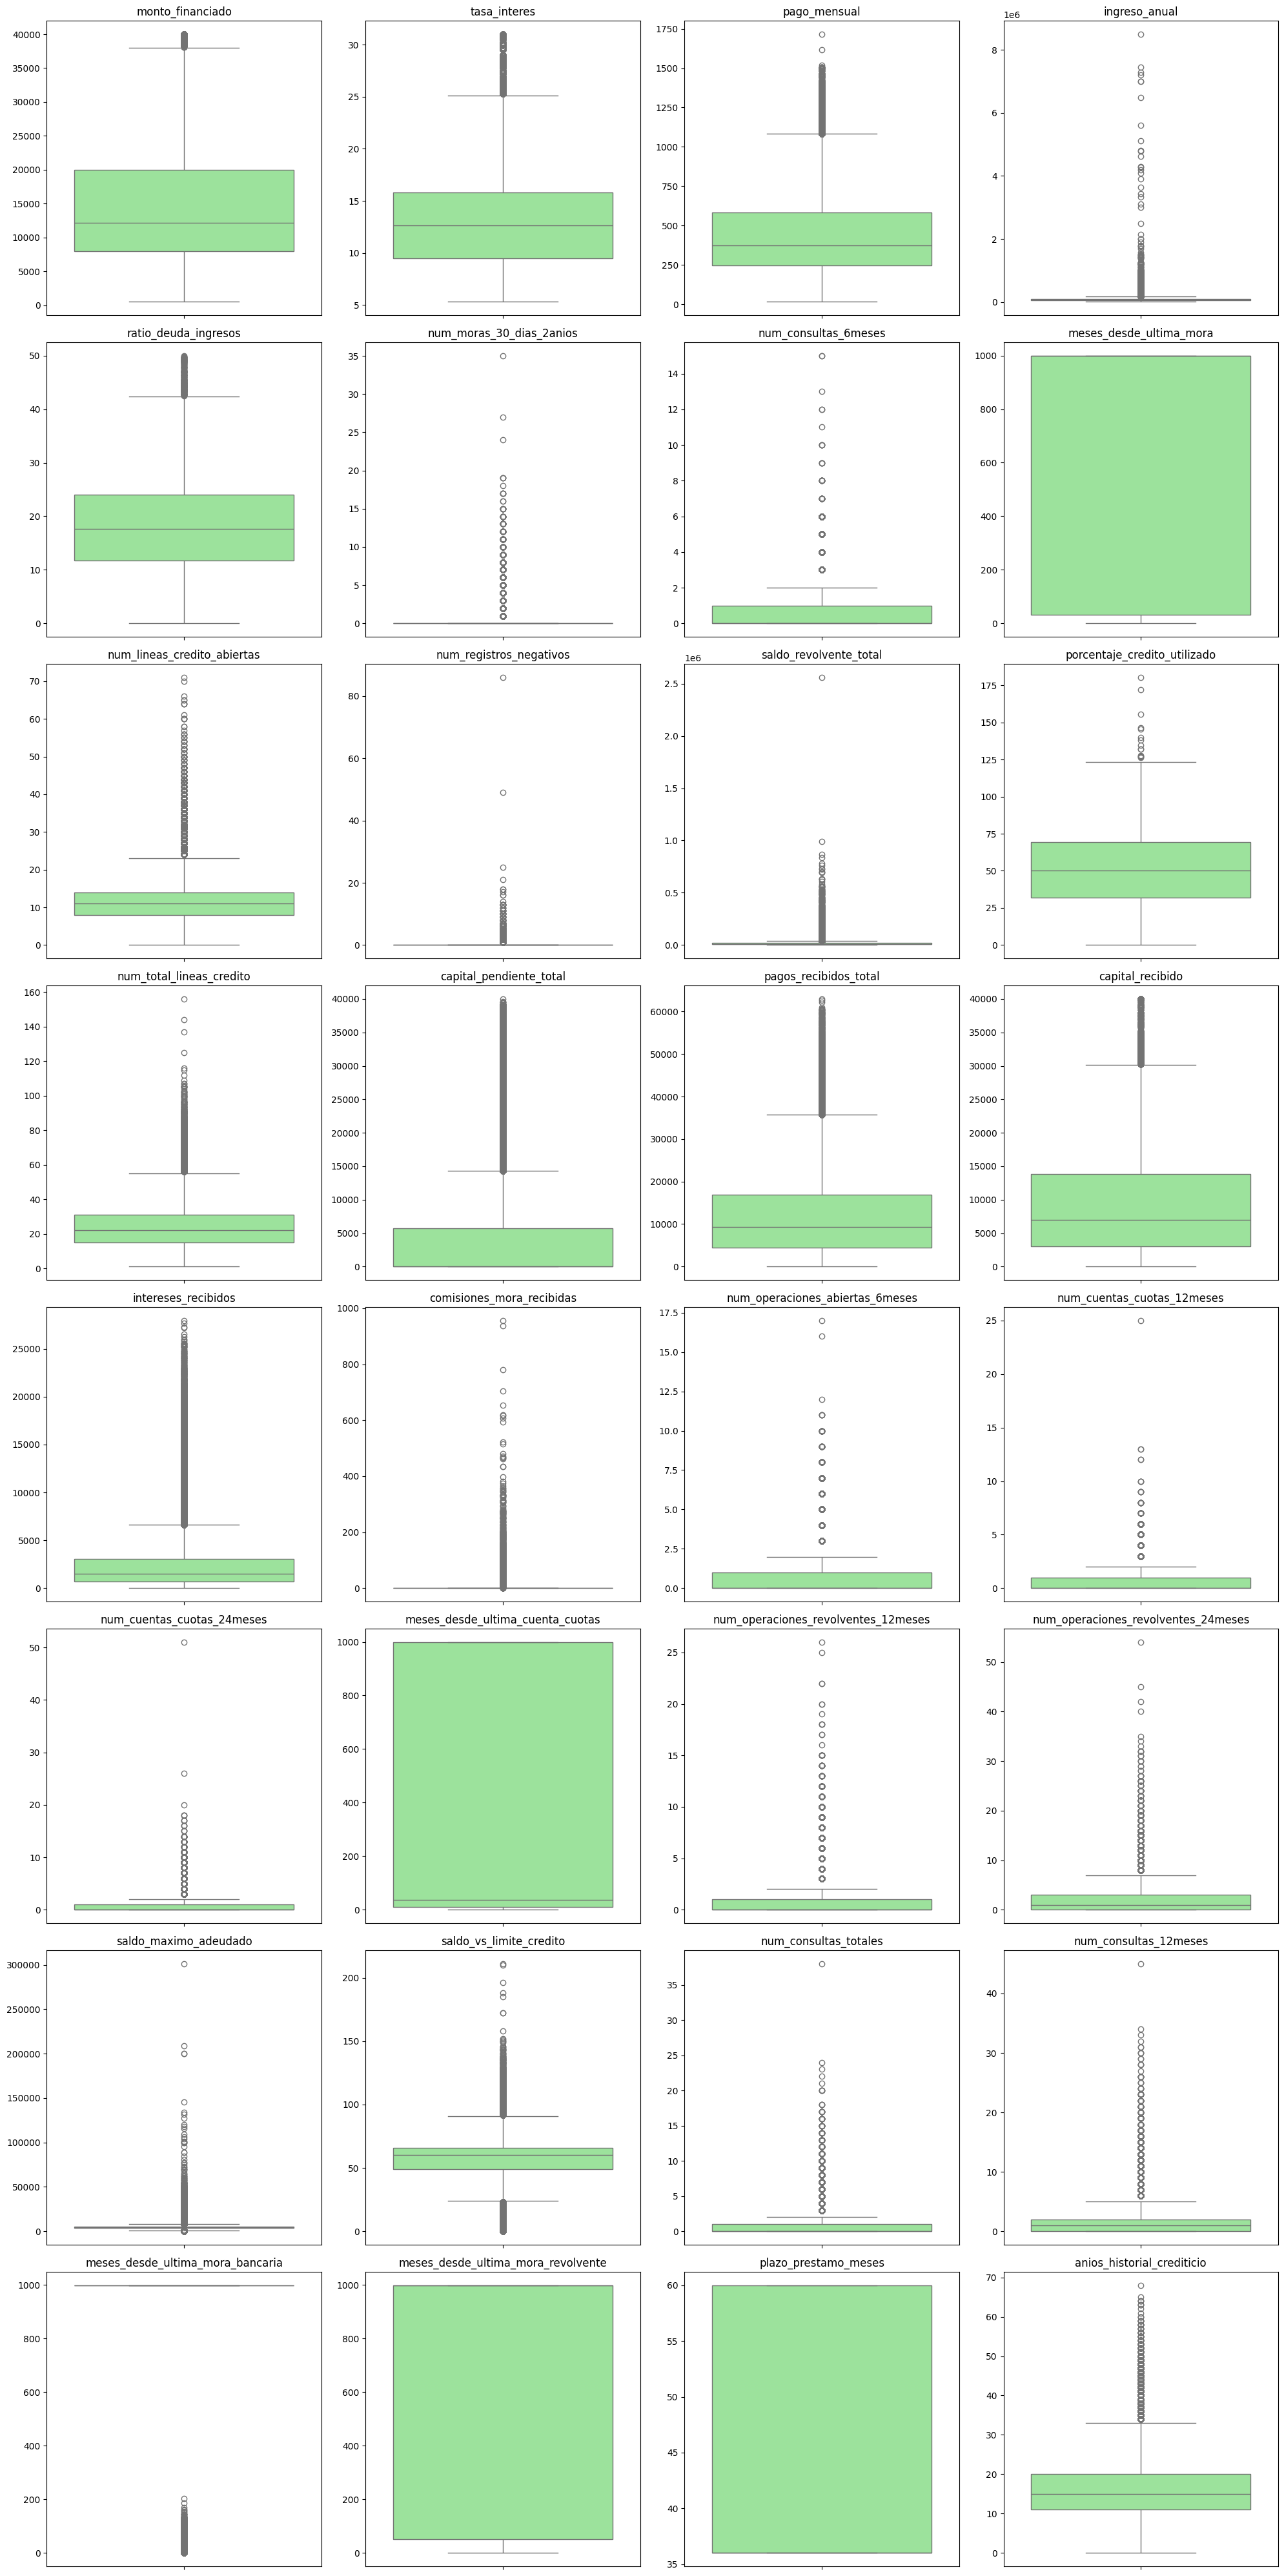

In [11]:
# Definimos cuántas columnas queremos en nuestra cuadrícula
cols_grid = 4
rows_grid = math.ceil(len(num_cols) / cols_grid)

plt.figure(figsize=(20, 5 * rows_grid))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows_grid, cols_grid, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(col)
    plt.ylabel('')

plt.tight_layout()
plt.show()


### 🧹 Limpieza de Variables y Prevención de "Data Leakage"

Tras el análisis exploratorio y de negocio, se ha decidido eliminar un grupo específico de variables para asegurar la integridad y la utilidad real del modelo de scoring.

#### Variables Eliminadas (Data Leakage):
* `capital_pendiente_total`
* `pagos_recibidos_total`
* `capital_recibido`
* `intereses_recibidos`
* `comisiones_mora_recibidas`

#### Justificación Técnica:
Estas variables representan información **post-originación**, es decir, datos que solo se generan una vez que el préstamo ya ha sido concedido y el cliente ha comenzado (o no) a pagar. 

1. **Prevención de Fuga de Datos (Leakage):** Si incluimos variables como `pagos_recibidos_total` para predecir el impago, el modelo aprendería una relación obvia (quien no paga, tiene pagos en cero), logrando una precisión artificialmente alta en los datos históricos.
2. **Validez del Modelo:** Un motor de Credit Scoring debe ser capaz de evaluar a un cliente en el **momento de la solicitud**. En ese instante, los pagos recibidos o intereses cobrados son siempre cero. Por tanto, eliminar estas variables garantiza que el modelo aprenda a predecir el riesgo basándose únicamente en el perfil crediticio y la capacidad financiera previa del solicitante.

> **Resultado:** El dataset ahora contiene exclusivamente variables **pre-originación**, lo que lo hace robusto para predecir el riesgo en nuevos préstamos.


In [12]:
# Lista de varaibles a  eliminar por ser "Leakage" (información del futuro)
cols_leakage = [
    'capital_pendiente_total', 
    'pagos_recibidos_total', 
    'capital_recibido', 
    'intereses_recibidos', 
    'comisiones_mora_recibidas'
]

# Eliminamos las varaibles del dataframe
df.drop(columns=cols_leakage, inplace=True)

# Quitamos las columnas de la lsita de columnas numericas
num_cols = [c for c in num_cols if c not in cols_leakage]

print(f"Se han eliminado {len(cols_leakage)} variables de fuga de datos.")
print(f"Variables numéricas finales: {len(num_cols)}")

Se han eliminado 5 variables de fuga de datos.
Variables numéricas finales: 27


In [13]:
def diagnostico_outliers(df, columnas):
    reporte = []
    
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lim_inf = Q1 - 1.5 * IQR
        lim_sup = Q3 + 1.5 * IQR
        
        # Identificar outliers
        outliers_inf = df[df[col] < lim_inf].shape[0]
        outliers_sup = df[df[col] > lim_sup].shape[0]
        total_outliers = outliers_inf + outliers_sup
        porcentaje = (total_outliers / len(df)) * 100
        
        reporte.append({
            'Variable': col,
            'Min': df[col].min(),
            'Limite Inf': lim_inf,
            'Limite Sup': lim_sup,
            'Max': df[col].max(),
            'Nº Outliers': total_outliers,
            '% Outliers': round(porcentaje, 2)
        })
    
    # Convertimos a DataFrame para verlo ordenado por porcentaje de impacto
    df_reporte = pd.DataFrame(reporte).sort_values(by='% Outliers', ascending=False)
    return df_reporte

In [14]:
pd.set_option('display.expand_frame_repr', False) # No expandir en varias líneas
pd.set_option('display.max_columns', None)      # Mostrar todas las columnas
pd.set_option('display.width', 1000)             # Ancho de consola extendido

# Ejecutamos el diagnóstico sobre todas las numéricas
# (Asegúrate de haber ejecutado num_cols antes)
reporte_outliers = diagnostico_outliers(df, num_cols)
# Mostramos solo las que tienen outliers para no ensuciar la vista
print("--- DIAGNÓSTICO DE OUTLIERS (REGLA 1.5xIQR) ---")
print(reporte_outliers[reporte_outliers['Nº Outliers'] > 0])

--- DIAGNÓSTICO DE OUTLIERS (REGLA 1.5xIQR) ---
                               Variable      Min   Limite Inf    Limite Sup         Max  Nº Outliers  % Outliers
23     meses_desde_ultima_mora_bancaria     0.00    999.00000     999.00000      999.00        49557       23.16
19                saldo_maximo_adeudado     0.00   1152.50000    7860.50000   301210.00        44674       20.88
5              num_moras_30_dias_2anios     0.00      0.00000       0.00000       35.00        40427       18.89
9               num_registros_negativos     0.00      0.00000       0.00000       86.00        33886       15.84
15           num_cuentas_cuotas_24meses     0.00     -1.50000       2.50000       51.00        27097       12.66
17  num_operaciones_revolventes_12meses     0.00     -1.50000       2.50000       26.00        21590       10.09
21                num_consultas_totales     0.00     -1.50000       2.50000       38.00        15671        7.32
20              saldo_vs_limite_credito     0.00

In [15]:
# Lista definitiva consensuada para Capping
variables_a_cappear = [
    'ingreso_anual', 
    'saldo_revolvente_total', 
    'saldo_maximo_adeudado', 
    'pago_mensual', 
    'num_total_lineas_credito',
    'monto_financiado'
]

print("--- APLICANDO CAPPING A VARIABLES CRÍTICAS ---")

for col in variables_a_cappear:
    # 1. Calculamos límites IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    
    # 2. Suelo de seguridad: el límite inferior no puede ser menor al mínimo lógico (0)
    lim_inf = max(df[col].min(), lim_inf)
    
    # 3. Aplicamos el ajuste (Capping)
    df[col] = df[col].clip(lower=lim_inf, upper=lim_sup)
    
    print(f"Variable '{col:25}': Ajustada al rango [{lim_inf:10.2f} , {lim_sup:10.2f}]")

print("\n¡Capping finalizado con éxito!")


--- APLICANDO CAPPING A VARIABLES CRÍTICAS ---
Variable 'ingreso_anual            ': Ajustada al rango [   3000.00 ,  166930.61]
Variable 'saldo_revolvente_total   ': Ajustada al rango [      0.00 ,   41605.12]
Variable 'saldo_maximo_adeudado    ': Ajustada al rango [   1152.50 ,    7860.50]
Variable 'pago_mensual             ': Ajustada al rango [     15.69 ,    1082.56]
Variable 'num_total_lineas_credito ': Ajustada al rango [      1.00 ,      55.00]
Variable 'monto_financiado         ': Ajustada al rango [    500.00 ,   38000.00]

¡Capping finalizado con éxito!


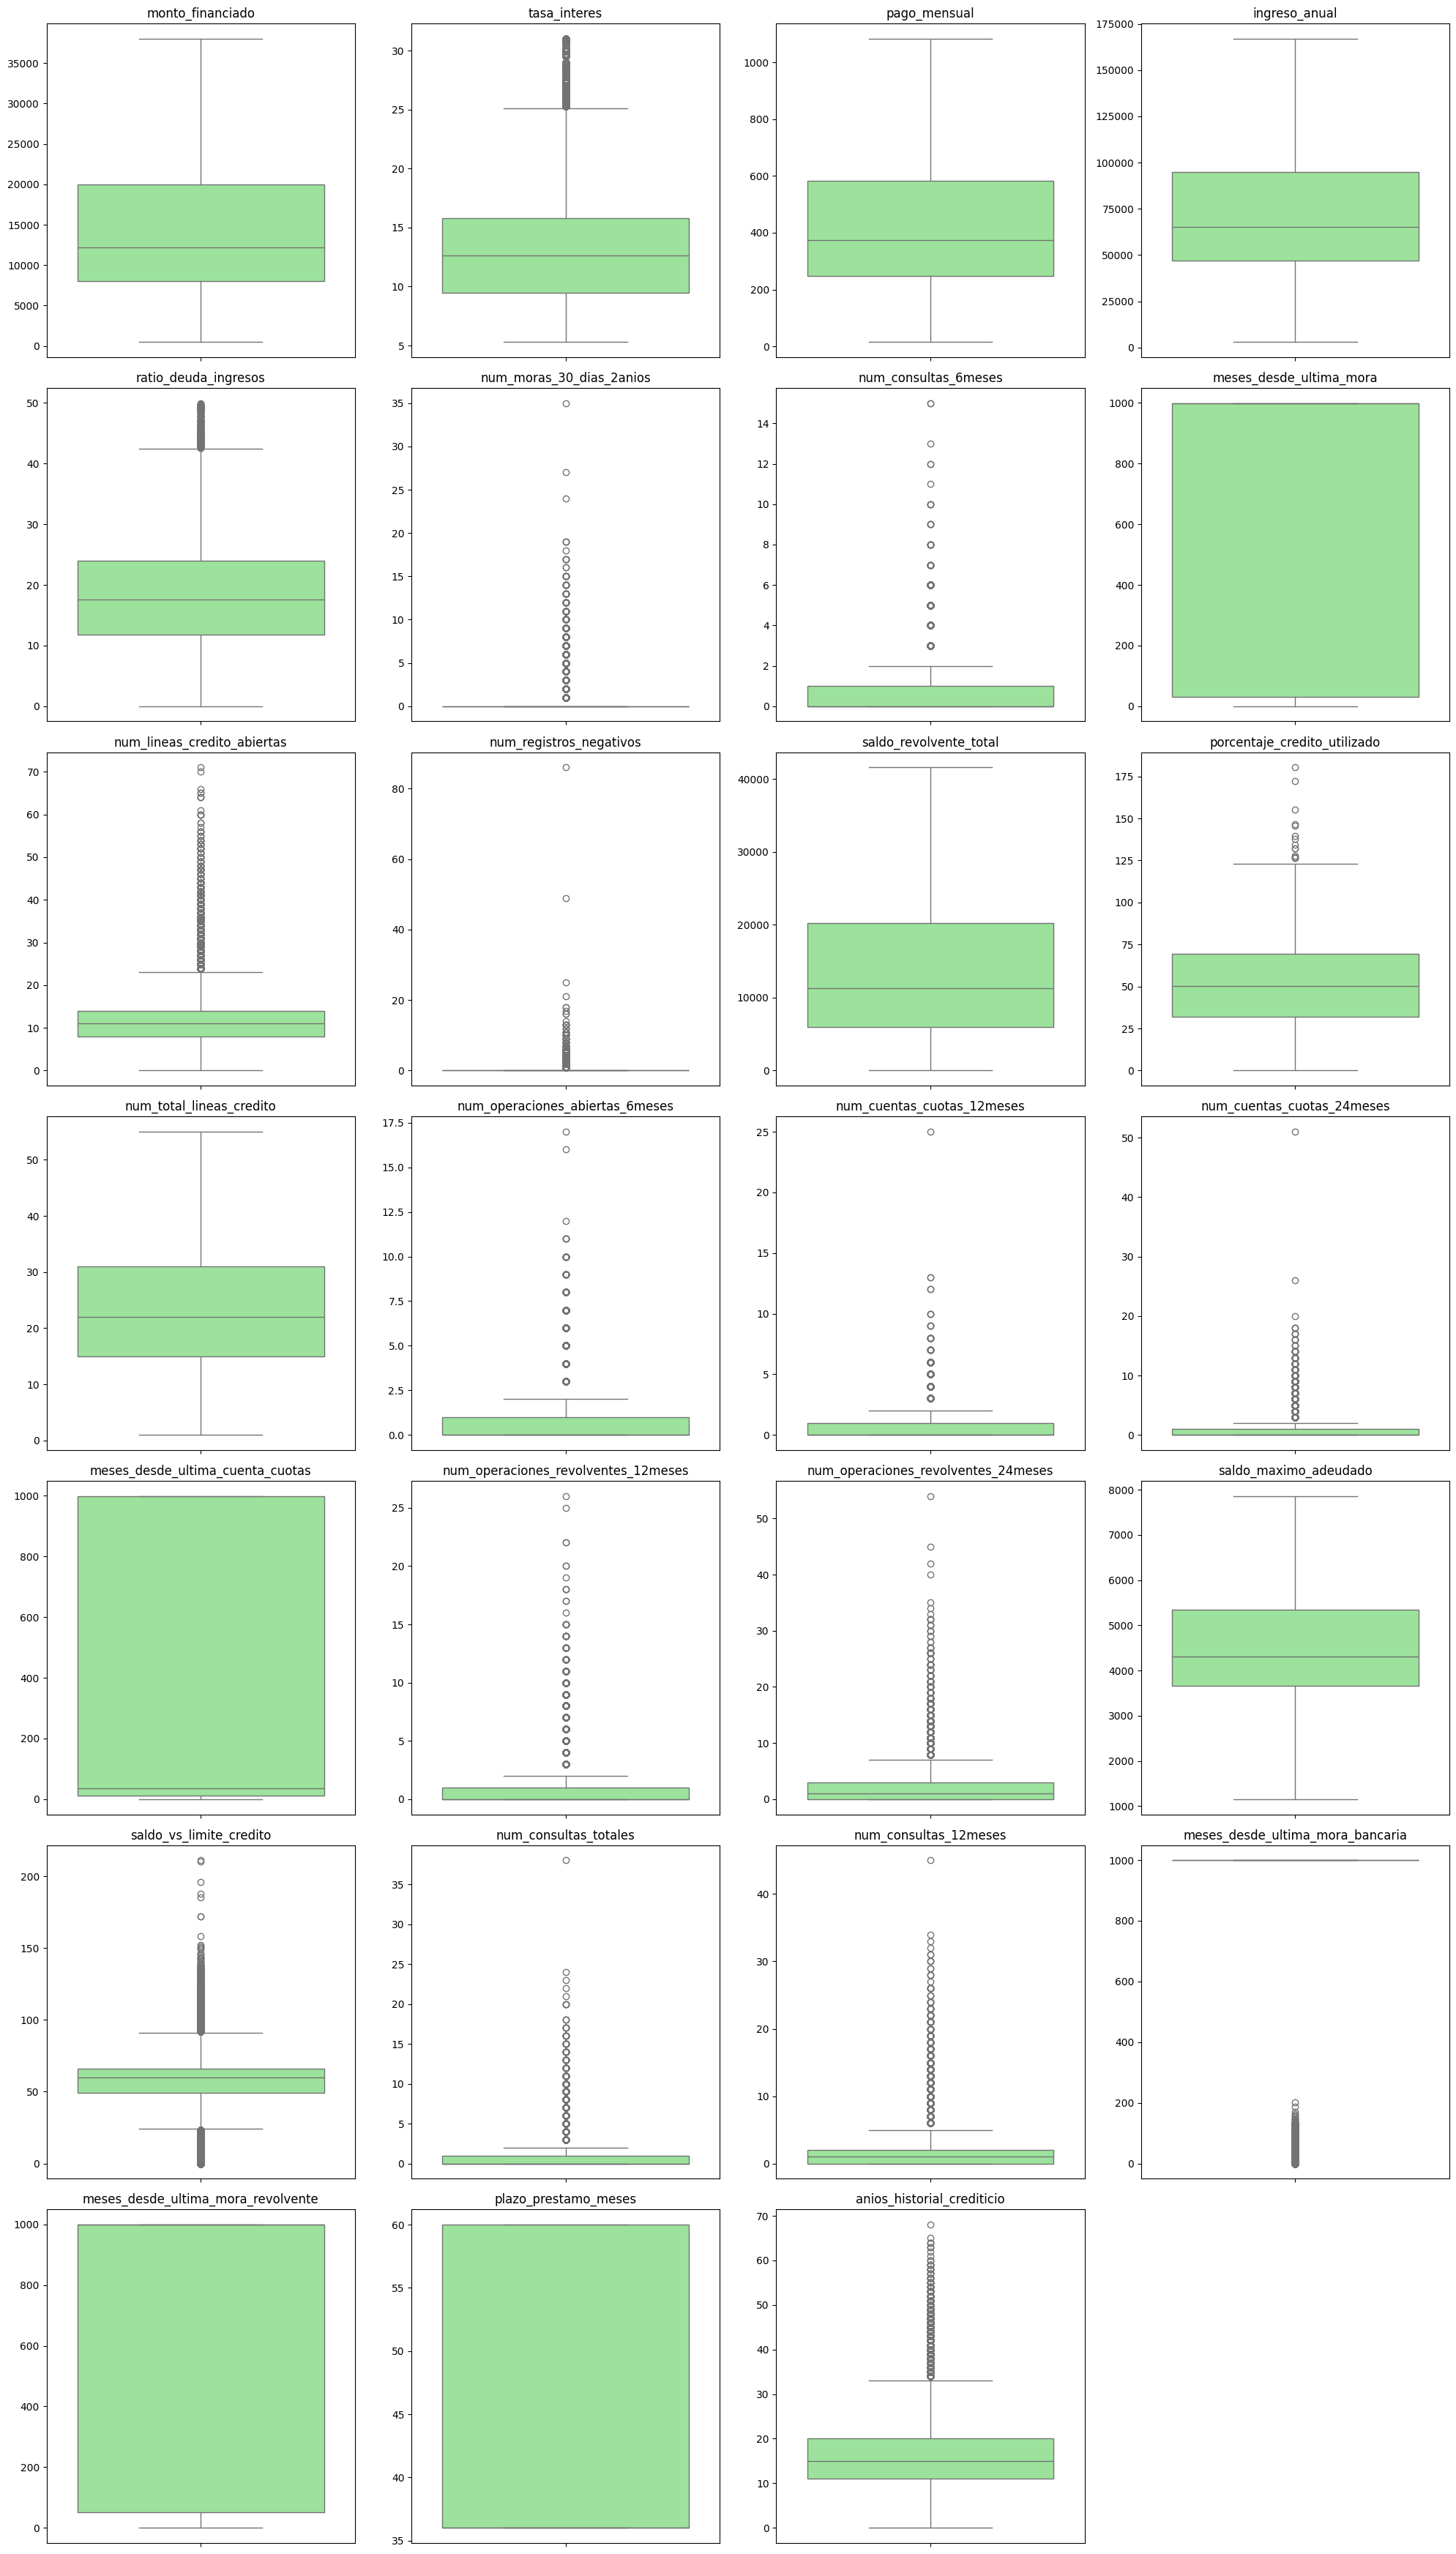

In [16]:
# Definimos cuántas columnas queremos en nuestra cuadrícula
cols_grid = 4
rows_grid = math.ceil(len(num_cols) / cols_grid)

plt.figure(figsize=(20, 5 * rows_grid))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows_grid, cols_grid, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(col)
    plt.ylabel('')

plt.tight_layout()
plt.show()


### 🛡️ Tratamiento de Outliers mediante Capping (Winsorización)

Tras el diagnóstico de valores atípicos, se ha aplicado la técnica de **Capping** basada en la regla del Rango Intercuartílico (1.5x IQR) para las variables de escala y montos monetarios.

**Motivos del Capping:**
1. **Protección del Modelo:** Los algoritmos de Machine Learning (especialmente los basados en distancias o regresiones) son altamente sensibles a valores extremos. Un solo ingreso de 8 millones de dólares puede desviar la línea de decisión y hacer que el modelo ignore al cliente promedio.
2. **Preservación de Información:** A diferencia de la eliminación de registros, el capping nos permite mantener la observación completa del cliente, ajustando únicamente el valor extremo a un límite estadísticamente razonable (el "whisker" superior).
3. **Estabilidad en las Métricas de Riesgo:** Al capear el `saldo_maximo_adeudado`, aseguramos que nuestra métrica de severidad (`LGD_Real`) sea estable y no presente valores absurdos (como pérdidas del 1000%), facilitando el aprendizaje del modelo en la Fase 3.

> **Nota:** Se ha respetado un suelo de **0** para todas las variables para mantener la coherencia financiera de los datos.


In [17]:
# --- CÁLCULO DE PARÁMETROS DE RIESGO ---

# Renombramos la variable para usar terminología financiera profesional
df.rename(columns={'monto_financiado': 'EAD'}, inplace=True)

# Severidad de la Pérdida (LGD_Real): % del capital que se estima perdido
# Usamos el saldo máximo ya capeado para evitar ruidos en la regresión
df['LGD_Real'] = (df['saldo_maximo_adeudado'] / df['EAD']) * 100

# Resumen de estado con columnas en lista vertical
print("✅ Fase de preparación numérica concluida.\n")
print("Métricas de riesgo creadas: EAD (Exposición) y LGD_Real (Severidad).\n")
print("📋 LISTADO FINAL DE COLUMNAS:")
print("-" * 30)
print("\n".join(df.columns))
print("-" * 30)
print(f"Total: {len(df.columns)} columnas.")


✅ Fase de preparación numérica concluida.

Métricas de riesgo creadas: EAD (Exposición) y LGD_Real (Severidad).

📋 LISTADO FINAL DE COLUMNAS:
------------------------------
EAD
tasa_interes
pago_mensual
grado
titulo_empleo
antiguedad_empleo
estado_vivienda
ingreso_anual
estado_verificacion
proposito_prestamo
estado_residencia
ratio_deuda_ingresos
num_moras_30_dias_2anios
num_consultas_6meses
meses_desde_ultima_mora
num_lineas_credito_abiertas
num_registros_negativos
saldo_revolvente_total
porcentaje_credito_utilizado
num_total_lineas_credito
estado_listado_inicial
num_operaciones_abiertas_6meses
num_cuentas_cuotas_12meses
num_cuentas_cuotas_24meses
meses_desde_ultima_cuenta_cuotas
num_operaciones_revolventes_12meses
num_operaciones_revolventes_24meses
saldo_maximo_adeudado
saldo_vs_limite_credito
num_consultas_totales
num_consultas_12meses
meses_desde_ultima_mora_bancaria
meses_desde_ultima_mora_revolvente
metodo_desembolso
plazo_prestamo_meses
codigo_region
target_moroso
anios_histori

In [18]:
# 1. Identificamos las categóricas actuales (aseguramos que la lista esté al día)
# cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Análisis de cardinalidad
print("--- ANÁLISIS DE VARIABLES CATEGÓRICAS ---")
for col in cat_cols:
    n_unicos = df[col].nunique()
    print(f"Variable: {col:25} | Categorías: {n_unicos}")

# 3. Revisión de valores (Corregido para imprimir TODAS las categorías de cat_cols)
print("\n--- DISTRIBUCIÓN DE CATEGORÍAS (TOP 5) ---")
for col in cat_cols: # Quitamos el comentario y lo aplicamos a todas
    print(f"\nTop 5 de {col}:")
    print(df[col].value_counts().head(5))


--- ANÁLISIS DE VARIABLES CATEGÓRICAS ---
Variable: grado                     | Categorías: 35
Variable: titulo_empleo             | Categorías: 78800
Variable: antiguedad_empleo         | Categorías: 12
Variable: estado_vivienda           | Categorías: 4
Variable: estado_verificacion       | Categorías: 3
Variable: proposito_prestamo        | Categorías: 14
Variable: estado_residencia         | Categorías: 51
Variable: estado_listado_inicial    | Categorías: 2
Variable: metodo_desembolso         | Categorías: 2
Variable: codigo_region             | Categorías: 10

--- DISTRIBUCIÓN DE CATEGORÍAS (TOP 5) ---

Top 5 de grado:
grado
C1    13980
B5    13388
B4    13332
B3    12664
C2    12445
Name: count, dtype: int64

Top 5 de titulo_empleo:
titulo_empleo
Unknown             14999
Teacher              3382
Manager              3184
Owner                2069
Registered Nurse     1483
Name: count, dtype: int64

Top 5 de antiguedad_empleo:
antiguedad_empleo
10+ years    71510
2 years      19

In [19]:
# Mapeo de la antiguedad del empleo
mapa_antiguedad = {
    '10+ years': 10, '9 years': 9, '8 years': 8, '7 years': 7, '6 years': 6,
    '5 years': 5, '4 years': 4, '3 years': 3, '2 years': 2, '1 year': 1,
    '< 1 year': 0, 'Unknown': -1 # Usamos 0 para identificar los que no sabemos
}
df['antiguedad_empleo'] = df['antiguedad_empleo'].map(mapa_antiguedad)

# Mapeo de grado (ordinal)
# Nota: Como hay 35 grados (A1...C1), vamos a usar un orden alfabético-numérico inverso
# para que el modelo entienda que a mayor letra/número, más riesgo.
grados_ordenados = sorted(df['grado'].unique())
mapa_grado = {grado: i for i, grado in enumerate(grados_ordenados)}
df['grado'] = df['grado'].map(mapa_grado)

# Actualizamos listas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Mapeo completado.")
print(f"Variables categóricas restantes para One-Hot: {cat_cols}")


Mapeo completado.
Variables categóricas restantes para One-Hot: ['titulo_empleo', 'estado_vivienda', 'estado_verificacion', 'proposito_prestamo', 'estado_residencia', 'estado_listado_inicial', 'metodo_desembolso']


C:\Users\jrglo\AppData\Local\Temp\ipykernel_62768\781999591.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


C:\Users\jrglo\AppData\Local\Temp\ipykernel_62768\3714510048.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='titulo', y='conteo', data=df_pareto.head(30), palette='viridis')


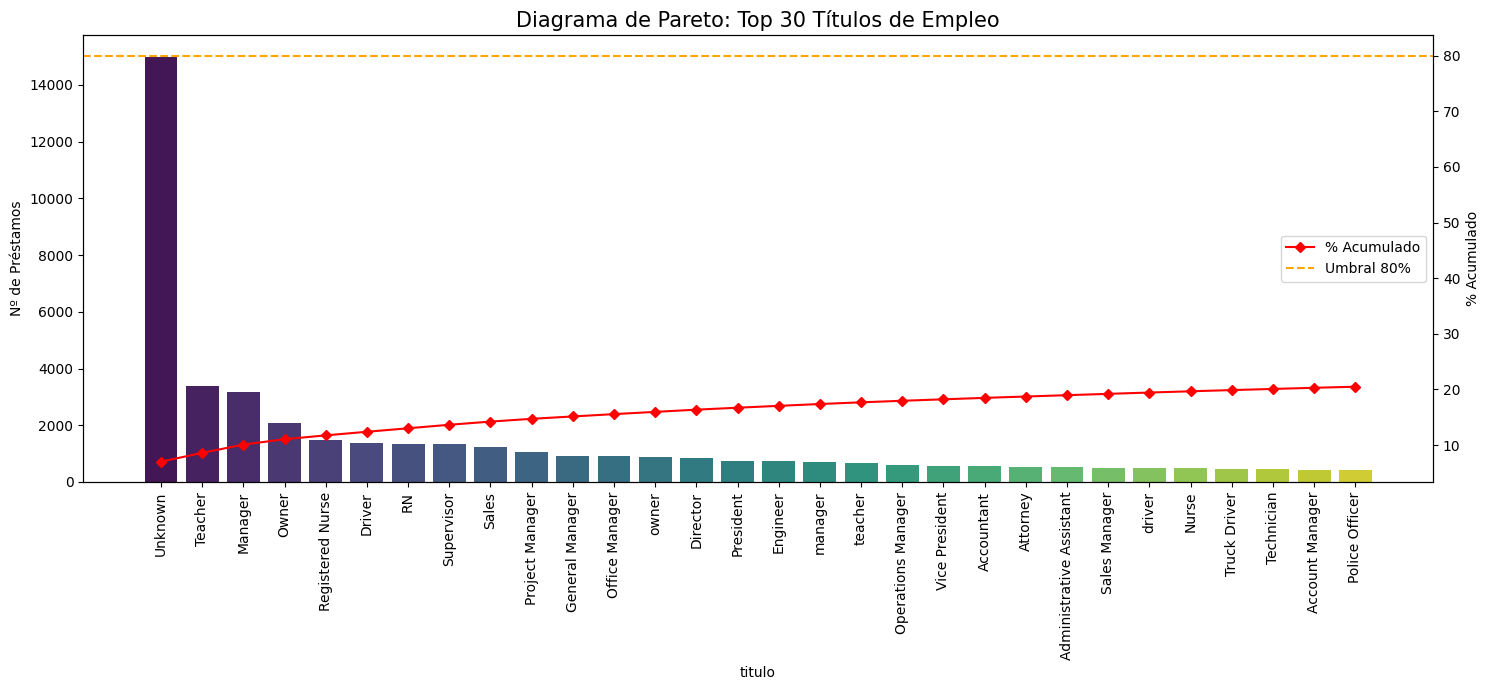

Número de títulos únicos necesarios para cubrir el 80% de la cartera: 36007


In [20]:
# Calculamos las frecuencias
frecuencia_empleos = df['titulo_empleo'].value_counts()
df_pareto = frecuencia_empleos.to_frame().reset_index()
df_pareto.columns = ['titulo', 'conteo']

# Calculamos el porcentaje acumulado
df_pareto['porc_acumulado'] = (df_pareto['conteo'].cumsum() / df_pareto['conteo'].sum()) * 100

# Visualización de Pareto (Top 30 empleos)
plt.figure(figsize=(15, 7))

# Barras de frecuencia
ax = sns.barplot(x='titulo', y='conteo', data=df_pareto.head(30), palette='viridis')
plt.xticks(rotation=90)

# Línea de acumulado
ax2 = ax.twinx()
ax2.plot(df_pareto['titulo'].head(30), df_pareto['porc_acumulado'].head(30), color='red', marker='D', ms=5, label='% Acumulado')
ax2.axhline(80, color='orange', linestyle='--', label='Umbral 80%') # Línea del 80%

ax.set_title('Diagrama de Pareto: Top 30 Títulos de Empleo', fontsize=15)
ax.set_ylabel('Nº de Préstamos')
ax2.set_ylabel('% Acumulado')
ax2.legend(loc='center right')

plt.tight_layout()
plt.show()

# Resumen numérico
n_titulos_80 = df_pareto[df_pareto['porc_acumulado'] <= 80].shape[0]
print(f"Número de títulos únicos necesarios para cubrir el 80% de la cartera: {n_titulos_80}")


### 📝 Justificación: Eliminación de la variable `titulo_empleo`

Tras realizar un análisis de **Pareto (80/20)** sobre los títulos de empleo declarados por los prestatarios, se ha decidido descartar esta variable para el modelo predictivo por los siguientes motivos:

1.  **Extrema Dispersión (Alta Cardinalidad):** El dataset presenta más de **78,000 categorías únicas**. El análisis de Pareto reveló que incluso agrupando los 30 títulos más frecuentes (como *Teacher* o *Manager*), apenas se cubre el **20%** de la cartera.
2.  **Inviabilidad Técnica (Dimensionalidad):** Aplicar técnicas de codificación como *One-Hot Encoding* sobre esta variable generaría miles de columnas nuevas, lo que provocaría el fenómeno conocido como "la maldición de la dimensionalidad", aumentando drásticamente el tiempo de cómputo y el riesgo de *overfitting* (sobreajuste).
3.  **Baja Calidad del Dato:** La categoría más frecuente es **"Unknown"**, lo que indica una falta de estandarización en la captura del dato original.
4.  **Sustitución por Proxies Eficientes:** La capacidad de pago y estabilidad laboral ya están representadas de forma mucho más limpia por las variables `ingreso_anual`, `grado` y `antiguedad_empleo`, las cuales no presentan el ruido semántico de los títulos de trabajo.

> **Decisión:** Se elimina la variable para simplificar el modelo y centrar el aprendizaje en predictores con mayor densidad de información y menos ruido.

In [21]:
# Eliminación de variables tras análisis de pareto
# Eliminamos 'titulo_empleo' por alta dispersión
df.drop(columns=['titulo_empleo'], inplace=True)

In [22]:
# Verificación final de nulos en todo el DataFrame
nulos_finales = df.isnull().sum()

print("--- VERIFICACIÓN FINAL DE HUECOS (NULOS) ---")
if nulos_finales.sum() == 0:
    print("¡Perfecto! El dataset está 100% limpio y listo para el modelo.")
else:
    print("¡Atención! Se han detectado nulos en las siguientes columnas:")
    print(nulos_finales[nulos_finales > 0])

# Verificación específica para nuestras métricas objetivo
print("\n--- CHEQUEO DE MÉTRICAS DE RIESGO ---")
print(f"Nulos en EAD:      {df['EAD'].isnull().sum()}")
print(f"Nulos en LGD_Real: {df['LGD_Real'].isnull().sum()}")


--- VERIFICACIÓN FINAL DE HUECOS (NULOS) ---
¡Perfecto! El dataset está 100% limpio y listo para el modelo.

--- CHEQUEO DE MÉTRICAS DE RIESGO ---
Nulos en EAD:      0
Nulos en LGD_Real: 0


### Fase 2: ¿Quién no nos va a pagar? (Modelo de Probabilidad de Impago - PD)
Necesitamos separar a los buenos clientes de los tóxicos usando un modelo de clasificación.

- Entrenamiento: Podéis usar el algoritmo de clasificación que queráis (Regresión Logística, Árboles, Random Forest, XGBoost...).

- Métrica de Decisión: No miréis el Accuracy. Quiero que maximicéis el Recall y el ROC-AUC. Prefiero rechazar a un cliente regular que dejar pasar a un moroso que nos cueste 20.000€.

- Entregable de esta fase: El modelo elegido y las probabilidades de impago (predict_proba) para cada cliente del conjunto de validación/test.



### Fase 3: Si no nos pagan, ¿cuánto perdemos? (Modelo de Severidad - LGD)
Aquí cambia el juego. Coged solo a los clientes que sabemos que son morosos (Target de la PD = 1) y entrenad un modelo de regresión para predecir el porcentaje de pérdida (Loss).

- Entrenamiento: Nuevamente, usad el algoritmo de regresión que prefiráis.

- Métrica de Decisión: Evaluad con el MAE y el RMSE. ¿Qué modelo se acerca más al porcentaje real de pérdida que calculamos en la Fase 1?

### Fase 4: El Veredicto Final (Expected Loss)
Ha llegado el momento de unir las piezas para el Comité de Dirección.

Tomad el conjunto de datos de Test (nuestra simulación del mundo real).

Usad el Modelo de PD para predecir la probabilidad de impago de cada préstamo.

Usad el Modelo de LGD para predecir el porcentaje de pérdida esperado.

Multiplicad los factores para calcular la pérdida esperada económica para cada cliente: 
$$
Pérdida\;Esperada = PD × (Loss / 100) × EAD
$$

Sumad la Pérdida Esperada de todos los clientes para obtener la cifra total de la cartera.

<br>

## 📊 Entregable Final: La Defensa
El Notebook debe terminar con una sección de conclusiones respondiendo a esto:

"Señores del Comité, de una cartera de Test valorada en [X] millones de dólares, nuestro motor estima que tendremos unas pérdidas por impago de [Y] millones de dólares."

Justificad la elección de vuestros modelos. ¿Son explicables ante el regulador o habéis optado por maximizar la precisión a costa de usar cajas negras?

Demostradme que no sois simples picadores de código, sino verdaderos Data Scientists financieros.